# Расчет Funding Rate по методике СПБ биржи

## Формула Funding Rate

Сначала рассчитывается Premium Index:

$$
PI = \frac{MeanPrice - MeanIndex}{MeanIndex} \times 100\% \times Kpi
$$

где `MeanPrice` — средняя цена perpetual, а `MeanIndex` — средняя референсная цена.

Далее:

$$
FundingRate =
\frac{IR}{365}
- Clamp(PI, [-R1, R1])
+ Clamp(PI, [-R2, R2])
$$

Для 26.08.2026:

- R1 = 2%
- R2 = 0%
- IR = 0%
- Kpi = 1
  
## Источники

- [Механизм фандинга СПБ Биржи](https://spbexchange.ru/spbfuture/funding/)
- [Спецификации и коэффициенты СПБ Биржи](https://spbexchange.ru/about/raskrytie_informacii/vn_norm_docs/specf_cv/)

## 1. Загрузка данных

Используются секундные данные Binance по BTC и ETH.  

In [2]:
import pandas as pd
import numpy as np

btc = pd.read_csv("aggregated/btc_aggregated_1s.csv")
eth = pd.read_csv("aggregated/eth_aggregated_1s.csv")

btc["timestamp"] = pd.to_datetime(btc["timestamp"])
eth["timestamp"] = pd.to_datetime(eth["timestamp"])

print("BTC:", btc["timestamp"].min(), "—", btc["timestamp"].max())
print("ETH:", eth["timestamp"].min(), "—", eth["timestamp"].max())

BTC: 2026-08-26 14:00:11+00:00 — 2026-08-26 19:59:10+00:00
ETH: 2026-08-26 14:00:11+00:00 — 2026-08-26 19:59:10+00:00


## 2. Перевод в минуты

По методике СПБ биржи из секундных данных берётся последнее доступное наблюдение каждой минуты.

В расчёте:
- `binance_perp_mid` используется как цена perpetual;
- `binance_spot_mid` используется как референсная цена.

In [3]:
btc_minute = (
    btc.set_index("timestamp")[["binance_perp_mid", "binance_spot_mid"]]
    .resample("1min")
    .last()
    .dropna()
)

eth_minute = (
    eth.set_index("timestamp")[["binance_perp_mid", "binance_spot_mid"]]
    .resample("1min")
    .last()
    .dropna()
)

print("BTC:", len(btc_minute), "минут")
print("ETH:", len(eth_minute), "минут")

BTC: 360 минут
ETH: 360 минут


## 3. Средние цены

Для каждого актива рассчитываются:

- `MeanPrice` — средняя минутная цена perpetual Binance.
- `MeanReference` — средняя минутная spot-цена Binance.

$$
MeanPrice = \frac{\sum Price_i}{N}
$$

$$
MeanReference = \frac{\sum Reference_i}{N}
$$

In [4]:
btc_mean_price = btc_minute["binance_perp_mid"].mean()
btc_mean_reference = btc_minute["binance_spot_mid"].mean()

eth_mean_price = eth_minute["binance_perp_mid"].mean()
eth_mean_reference = eth_minute["binance_spot_mid"].mean()

print("BTC")
print("MeanPrice:", btc_mean_price)
print("MeanReference:", btc_mean_reference)

print("\nETH")
print("MeanPrice:", eth_mean_price)
print("MeanReference:", eth_mean_reference)

BTC
MeanPrice: 78216.94861111112
MeanReference: 78250.21552777778

ETH
MeanPrice: 2455.7431111111114
MeanReference: 2456.7801666666664


## 4. Premium Index

Premium Index показывает относительное отклонение средней цены perpetual от средней референсной цены.

$$
PI =
\frac{MeanPrice - MeanReference}{MeanReference}
\times 100\%
\times Kpi
$$

Для наших данных используется коэффициент:

$$
Kpi = 1
$$

In [5]:
Kpi = 1

btc_pi = (
    (btc_mean_price - btc_mean_reference)
    / btc_mean_reference
    * 100
    * Kpi
)

eth_pi = (
    (eth_mean_price - eth_mean_reference)
    / eth_mean_reference
    * 100
    * Kpi
)

print("BTC Premium Index:", btc_pi, "%")
print("ETH Premium Index:", eth_pi, "%")

BTC Premium Index: -0.042513514425849476 %
ETH Premium Index: -0.04221198012039217 %


## 5. Funding Rate

Funding Rate рассчитывается по формуле СПБ Биржи:

$$
FundingRate =
\frac{IR}{365}
-
Clamp(PI, [-R1, R1])
+
Clamp(PI, [-R2, R2])
$$

Для 26.08.2026:

- `R1 = 2%`
- `R2 = 0%`
- `IR = 0%`
- `Kpi = 1`

При этих параметрах формула упрощается до:

$$
FundingRate = -Clamp(PI, [-2\%, 2\%])
$$

In [6]:
R1 = 2.0
R2 = 0.0
IR = 0.0

btc_funding_rate = (
    IR / 365
    - np.clip(btc_pi, -R1, R1)
    + np.clip(btc_pi, -R2, R2)
)

eth_funding_rate = (
    IR / 365
    - np.clip(eth_pi, -R1, R1)
    + np.clip(eth_pi, -R2, R2)
)

print("BTC Funding Rate:", btc_funding_rate, "%")
print("ETH Funding Rate:", eth_funding_rate, "%")

BTC Funding Rate: 0.042513514425849476 %
ETH Funding Rate: 0.04221198012039217 %


## 6. Итоговый результат

Положительное значение Funding Rate значит, что по механизму СПБ Биржи выплату производит продавец (short), а покупатель (long) получает её.

В данном расчёте perpetual Binance в среднем торговался ниже spot-цены, поэтому Premium Index получился отрицательным, а Funding Rate — положительным.

In [7]:
result = pd.DataFrame({
    "Asset": ["BTC", "ETH"],
    "MeanPrice": [btc_mean_price, eth_mean_price],
    "MeanReference": [btc_mean_reference, eth_mean_reference],
    "PremiumIndex_%": [btc_pi, eth_pi],
    "FundingRate_%": [btc_funding_rate, eth_funding_rate]
})

result.round(6)

,Asset,MeanPrice,MeanReference,PremiumIndex_%,FundingRate_%
0,BTC,78216.948611,78250.215528,-0.042514,0.042514
1,ETH,2455.743111,2456.780167,-0.042212,0.042212


## Динамика расчётного Funding Rate

График показывает изменение расчётного Funding Rate для BTC и ETH по данным Binance за весь записанный период. Расчёт выполнен с использованием минутных наблюдений: для каждой точки учитываются накопленные средние значения цены perpetual и референсной spot-цены от начала периода до соответствующей минуты.

Положительное значение Funding Rate в данном расчёте означает выплату в сторону long-позиции, отрицательное — в сторону short-позиции. Последняя точка графика соответствует итоговому Funding Rate, рассчитанному по всему исследуемому периоду.

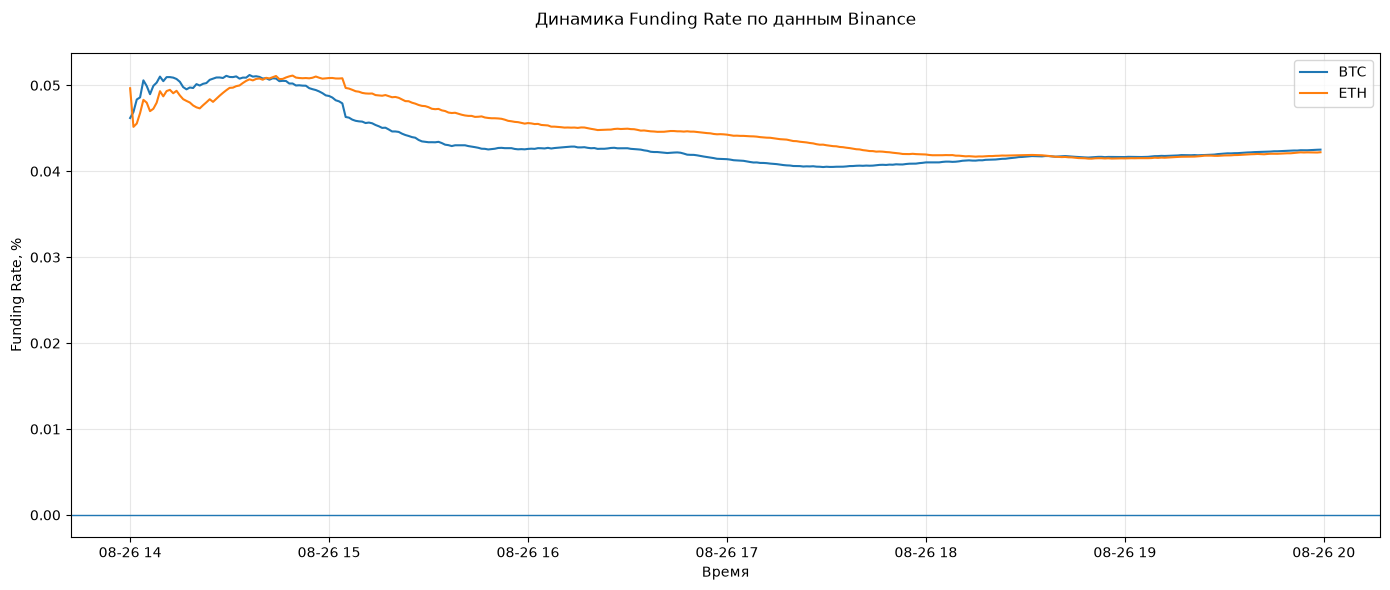

BTC Funding Rate: 0.042514 %
ETH Funding Rate: 0.042212 %


In [9]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt


# Копирую минутные данные
btc_funding = btc_minute.copy()
eth_funding = eth_minute.copy()

btc_funding["MeanPrice"] = (
    btc_funding["binance_perp_mid"]
    .expanding()
    .mean()
)

btc_funding["MeanReference"] = (
    btc_funding["binance_spot_mid"]
    .expanding()
    .mean()
)

eth_funding["MeanPrice"] = (
    eth_funding["binance_perp_mid"]
    .expanding()
    .mean()
)

eth_funding["MeanReference"] = (
    eth_funding["binance_spot_mid"]
    .expanding()
    .mean()
)


# Premium Index
btc_funding["PremiumIndex"] = (
    (btc_funding["MeanPrice"] - btc_funding["MeanReference"])
    / btc_funding["MeanReference"]
    * 100
    * Kpi
)

eth_funding["PremiumIndex"] = (
    (eth_funding["MeanPrice"] - eth_funding["MeanReference"])
    / eth_funding["MeanReference"]
    * 100
    * Kpi
)


# Funding Rate — та же формула,
# которую мы уже использовали в notebook

btc_funding["FundingRate"] = (
    IR / 365
    - np.clip(btc_funding["PremiumIndex"], -R1, R1)
    + np.clip(btc_funding["PremiumIndex"], -R2, R2)
)

eth_funding["FundingRate"] = (
    IR / 365
    - np.clip(eth_funding["PremiumIndex"], -R1, R1)
    + np.clip(eth_funding["PremiumIndex"], -R2, R2)
)


# ----- ГРАФИК -----

plt.figure(figsize=(14, 6))

plt.plot(
    btc_funding.index,
    btc_funding["FundingRate"],
    label="BTC"
)

plt.plot(
    eth_funding.index,
    eth_funding["FundingRate"],
    label="ETH"
)

# Нулевая линия
plt.axhline(0, linewidth=1)

plt.title(
    "Динамика Funding Rate по данным Binance\n"
)

plt.xlabel("Время")
plt.ylabel("Funding Rate, %")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Сохранение картинки рядом с notebook
plt.savefig(
    "funding_rate_over_time.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Контроль итоговых значений
print(
    "BTC Funding Rate:",
    round(btc_funding["FundingRate"].iloc[-1], 6),
    "%"
)

print(
    "ETH Funding Rate:",
    round(eth_funding["FundingRate"].iloc[-1], 6),
    "%"
)

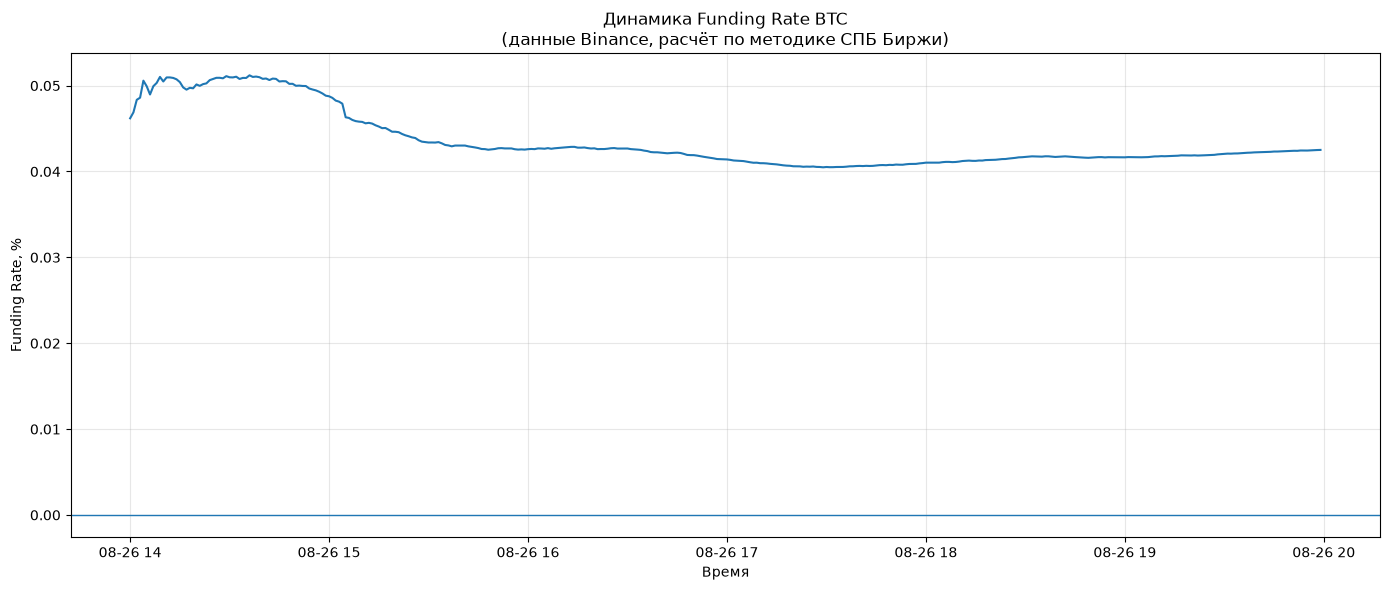

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    btc_funding.index,
    btc_funding["FundingRate"]
)

plt.axhline(0, linewidth=1)

plt.title(
    "Динамика Funding Rate BTC\n"
    "(данные Binance, расчёт по методике СПБ Биржи)"
)

plt.xlabel("Время")
plt.ylabel("Funding Rate, %")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "iframe_figures/btc_funding_rate.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

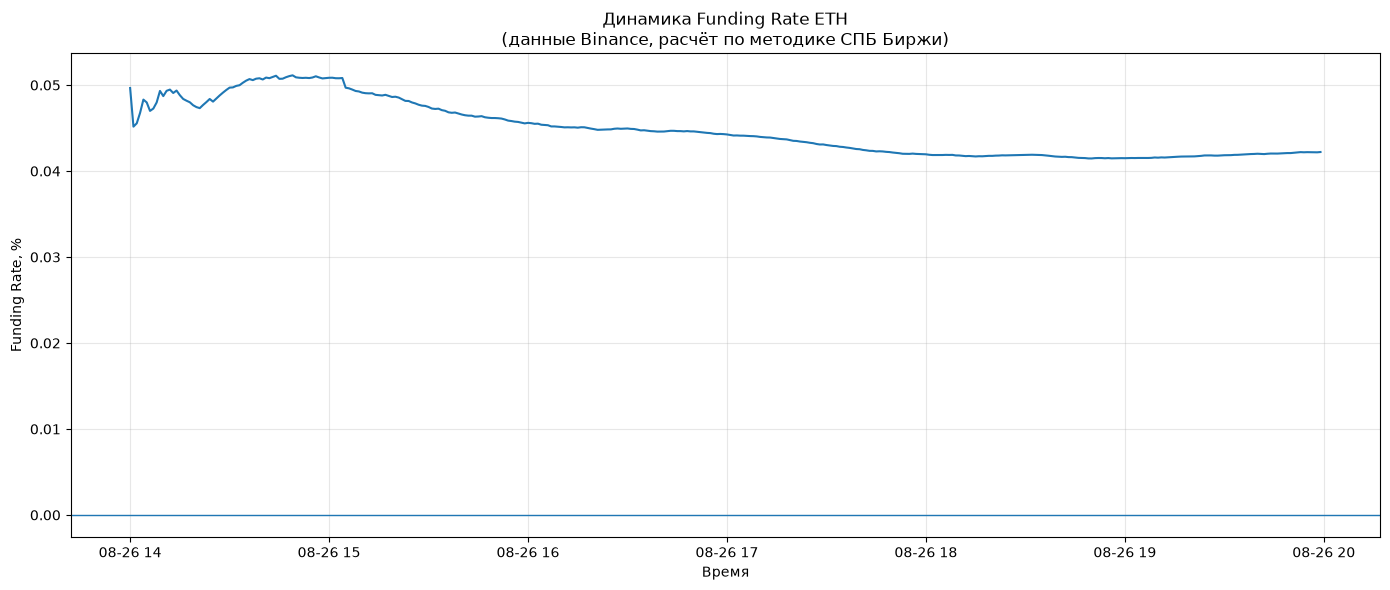

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(
    eth_funding.index,
    eth_funding["FundingRate"]
)

plt.axhline(0, linewidth=1)

plt.title(
    "Динамика Funding Rate ETH\n"
    "(данные Binance, расчёт по методике СПБ Биржи)"
)

plt.xlabel("Время")
plt.ylabel("Funding Rate, %")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "iframe_figures/eth_funding_rate.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Спред между фьючерсом и базовым активом

Для анализа механики Funding Rate дополнительно рассчитывается спред между ценой perpetual-контракта и ценой базового актива.

Для обоих рынков используется mid-price — середина между лучшими ценами bid и offer:

**MidPrice = (Bid + Ask) / 2**

В агрегированных данных эти значения представлены как `binance_perp_mid` и `binance_spot_mid`.

Спред рассчитывается как:

**Spread = Perpetual MidPrice − Spot MidPrice**

Положительный спред означает, что perpetual торгуется выше базового актива, отрицательный — ниже.

In [12]:
# Спред между perpetual и базовым активом

btc_funding["Spread_USD"] = (
    btc_funding["binance_perp_mid"]
    - btc_funding["binance_spot_mid"]
)

eth_funding["Spread_USD"] = (
    eth_funding["binance_perp_mid"]
    - eth_funding["binance_spot_mid"]
)

print("BTC spread:")
print(btc_funding["Spread_USD"].describe())

print("\nETH spread:")
print(eth_funding["Spread_USD"].describe())

BTC spread:
count    360.000000
mean     -33.266917
std        7.509739
min      -48.675000
25%      -38.492500
50%      -33.610000
75%      -28.982500
max       44.455000
Name: Spread_USD, dtype: float64

ETH spread:
count    360.000000
mean      -1.037056
std        0.213992
min       -1.510000
25%       -1.180000
50%       -1.030000
75%       -0.900000
max        0.580000
Name: Spread_USD, dtype: float64


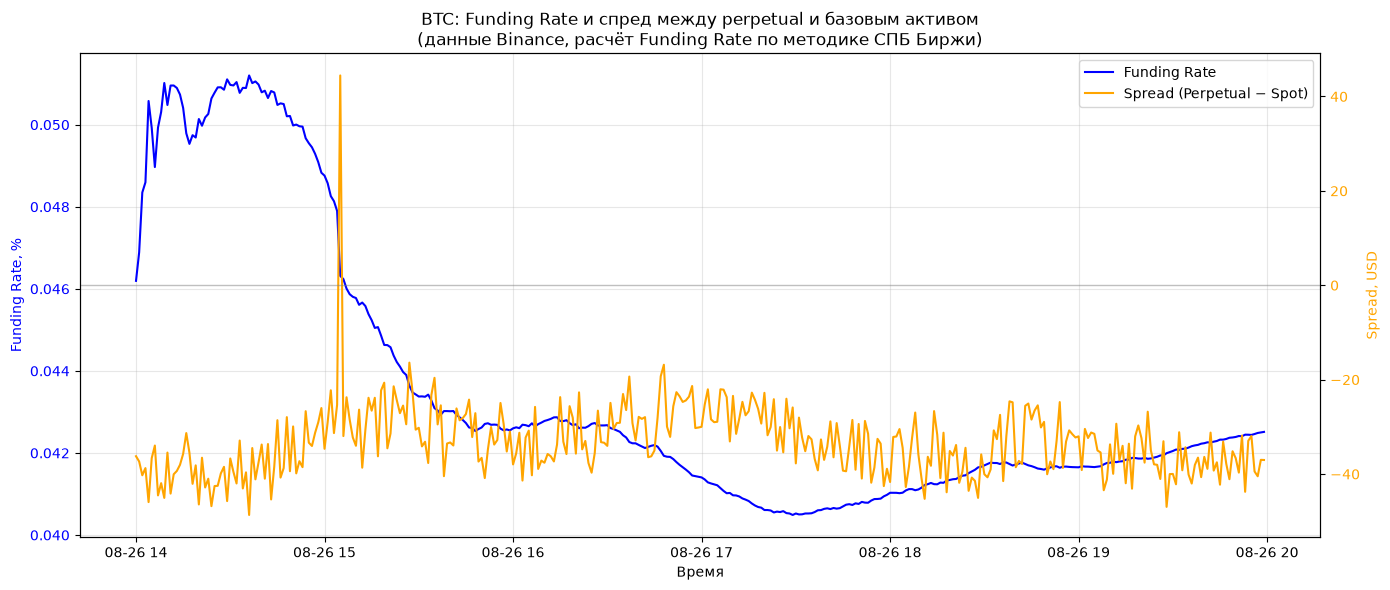

In [16]:
# BTC: Funding Rate + Spread

fig, ax1 = plt.subplots(figsize=(14, 6))

# Funding Rate — левая ось
line1 = ax1.plot(
    btc_funding.index,
    btc_funding["FundingRate"],
    label="Funding Rate",
    color="blue",
    linewidth=1.5
)

ax1.set_xlabel("Время")
ax1.set_ylabel("Funding Rate, %", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(alpha=0.3)


# Spread — правая ось
ax2 = ax1.twinx()

line2 = ax2.plot(
    btc_funding.index,
    btc_funding["Spread_USD"],
    label="Spread (Perpetual − Spot)",
    color="orange",
    linewidth=1.5
)

ax2.set_ylabel("Spread, USD", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")


# Нулевая линия спреда
ax2.axhline(
    0,
    color="gray",
    linewidth=1,
    alpha=0.5
)


# Общая легенда
lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc="upper right"
)


plt.title(
    "BTC: Funding Rate и спред между perpetual и базовым активом\n"
    "(данные Binance, расчёт Funding Rate по методике СПБ Биржи)"
)

fig.tight_layout()

plt.savefig(
    "iframe_figures/btc_funding_rate_spread.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

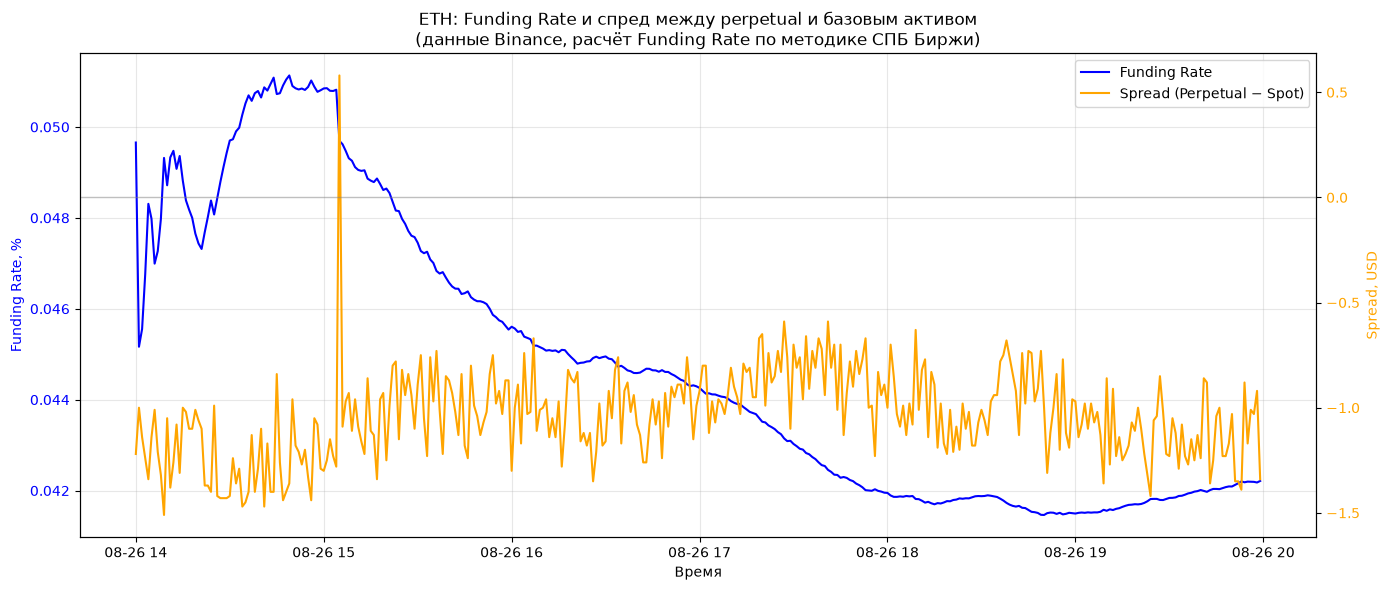

In [19]:
# ETH: Funding Rate + Spread

fig, ax1 = plt.subplots(figsize=(14, 6))

# Funding Rate — левая ось
line1 = ax1.plot(
    eth_funding.index,
    eth_funding["FundingRate"],
    label="Funding Rate",
    color="blue",
    linewidth=1.5
)

ax1.set_xlabel("Время")
ax1.set_ylabel("Funding Rate, %", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(alpha=0.3)

# Spread — правая ось
ax2 = ax1.twinx()

line2 = ax2.plot(
    eth_funding.index,
    eth_funding["Spread_USD"],
    label="Spread (Perpetual − Spot)",
    color="orange",
    linewidth=1.5
)

ax2.set_ylabel("Spread, USD", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

# Нулевая линия спреда
ax2.axhline(
    0,
    color="gray",
    linewidth=1,
    alpha=0.5
)

# Общая легенда
lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc="upper right"
)

plt.title(
    "ETH: Funding Rate и спред между perpetual и базовым активом\n"
    "(данные Binance, расчёт Funding Rate по методике СПБ Биржи)"
)

fig.tight_layout()

plt.savefig(
    "iframe_figures/eth_funding_rate_spread.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Funding Rate изменяется более плавно, чем текущий спред, поскольку рассчитывается на основе накопленных средних значений perpetual и spot за весь пройденный период, а не по одной минуте.